In [122]:
import numpy as np
from scipy.ndimage import laplace, sobel
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

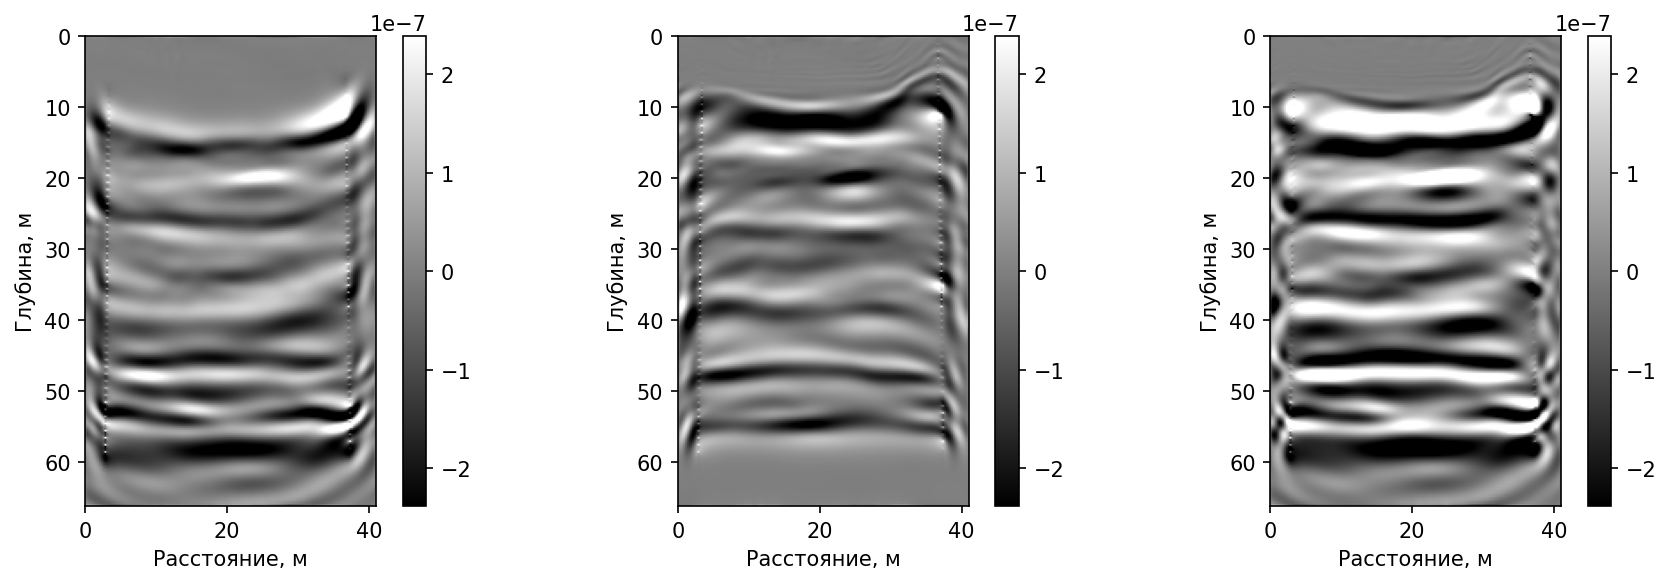

In [163]:
grad_u = np.load("gradients/grad_full_u_0.npy")
grad_d = np.load("gradients/grad_full_d_0.npy")
image = np.load("images/image_iter_0.npy")
sobel_h = sobel(image, 0)  # horizontal gradient
sobel_v = sobel(image, 1)  # vertical gradient
magnitude = np.sqrt(sobel_h**2 + sobel_v**2)
# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
glmax = max([np.quantile(grad_d, 0.99), np.quantile(grad_u, 0.99)])

for gr, ax in zip([grad_d, grad_u, grad_d-grad_u], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(np.diff(gr.T, axis=0, n=1), cmap='gray', vmin=-glmax, vmax=glmax)
    # h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/10, vmax=glmax/10, extent=[0, grad_d.shape[0]*0.25, grad_d.shape[1]*0.25, 0])
    h=ax.imshow(gr.T, cmap='gray', vmin=-glmax/1, vmax=glmax/1, extent=[0, grad_d.shape[0]*0.25, grad_d.shape[1]*0.25, 0])
    # ax.imshow(image.T, cmap='jet', extent=[0, grad_d.shape[0], grad_d.shape[1], 0], alpha=0.25,)
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()
# plt.savefig("pngs/grad.png")
# plt.close()

In [164]:
from image_update import upsample_image

def get_model_shape():
    return 1630, 2640

grad_upsampled = upsample_image(grad_d-grad_u, *get_model_shape())
print(grad_upsampled.shape)
np.save("../lsrtm/images/image_iter_0.npy", grad_upsampled)

(1630, 2640)


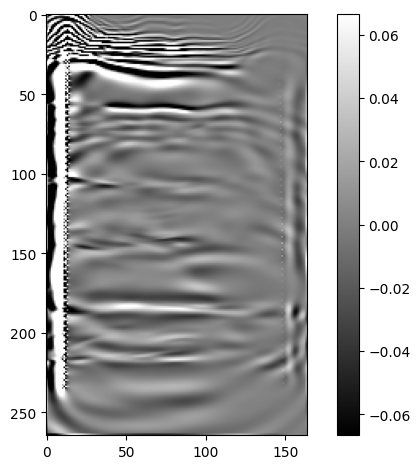

In [91]:
grad1 = np.load("gradients/grad_full_0.npy")
buff = grad1.T*1000
qa = np.quantile(buff, 0.99)
# h=plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)
h=plt.imshow(laplace(buff), cmap='gray', vmin=-qa/1e1, vmax=qa/1e1)

plt.colorbar(h)
plt.tight_layout()
plt.show()

In [ ]:

from config import *
import torch
def get_model_shape():
    return 1630, 2640

def get_num_shots():
    return 59
def load_wavefield_snaps_batch(shot_ids, wavefield_type='forward'):
    dir_path = OUTPUT_DIRS['forward_snaps'] if wavefield_type == 'forward' else OUTPUT_DIRS['adjoint_snaps']
    nx, nz = get_model_shape()
    sub_nx = nx // SUBSAMPLING + 1
    sub_nz = nz // SUBSAMPLING + 1
    
    batch = torch.empty((len(shot_ids), NSNAPS, sub_nx, sub_nz),
                    dtype=torch.float32,
                    pin_memory=True)
    
    for i, shot_id in enumerate(shot_ids):
        path = f"{dir_path}/{shot_id+1}.npy"
        batch[i] = torch.from_numpy(np.load(path))  # Copy forces read into memory
    
    return batch

In [13]:
shot_ids = range(0, get_num_shots(), 10)
# shot_ids = range(0, 6)

u0_batch = load_wavefield_snaps_batch(shot_ids, 'forward')
v_batch = load_wavefield_snaps_batch(shot_ids, 'adjoint')

print(u0_batch.numpy().shape)

(6, 500, 164, 265)


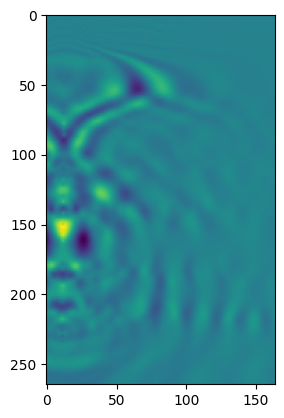

In [14]:
plt.imshow(np.diff(v_batch.numpy(), axis=1, n=2)[4][200].T)
plt.show()

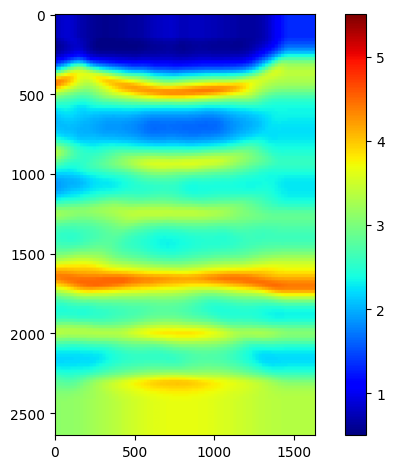

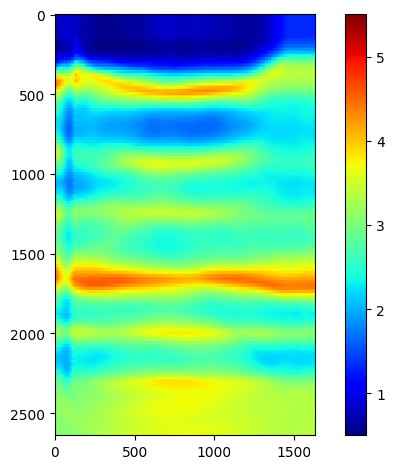

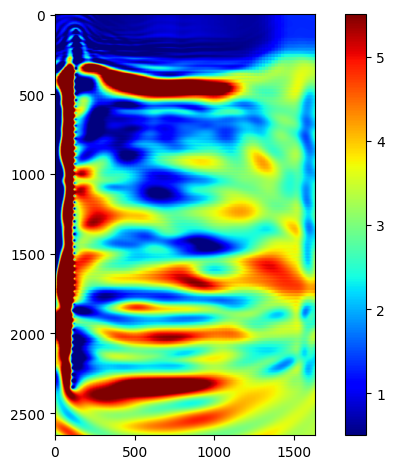

In [66]:
for i in range(0, 3):
    path = f"images/image_iter_{i}.npy"
    grad1 = np.load(path)
    buff = grad1.T
    # h = plt.imshow(buff, cmap='jet', vmin=qa1, vmax=qa2)
    h = plt.imshow(buff, cmap='jet', vmin=0.5, vmax=5.5)
    plt.gcf().colorbar(h)
    plt.tight_layout()
    plt.savefig(f"pngs/_{i}.png")
    plt.show()

In [8]:
from wavefield_computation import setup_model_and_geometry
import numpy as np
model, dataset = setup_model_and_geometry(29)

(1630, 2640)


Operator `initdamp` ran in 0.01 s


In [5]:
from config import *
d_syn = np.load(f"{OUTPUT_DIRS['forward_snaps']}/recon_gather_{20}.npy")
print(d_syn.shape)

(12984, 57)


In [6]:
dataset._dt_r = model.critical_dt
dataset._t_max_r = 40.0
dataset.resample_on()
d_obs = dataset[20][0]
print(d_obs.shape)

(57, 12984)


In [7]:
print(np.quantile(d_obs, 0.99))
print(np.quantile(d_syn, 0.99))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn.ravel()**2))
print(scale_factor)

3.218513935875701
0.006853265
446.16755457217005


In [9]:

d_obs /= scale_factor

In [11]:
print(np.linalg.norm(d_syn.ravel()))
print(np.linalg.norm(d_obs.ravel()))

2.1409204
2.140921592712403


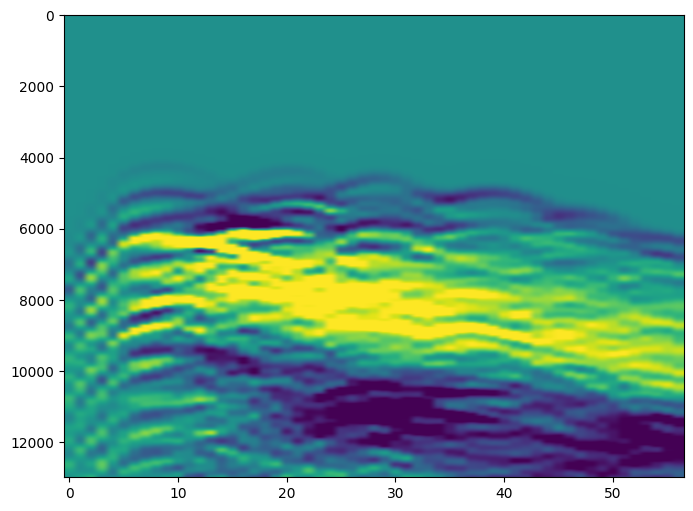

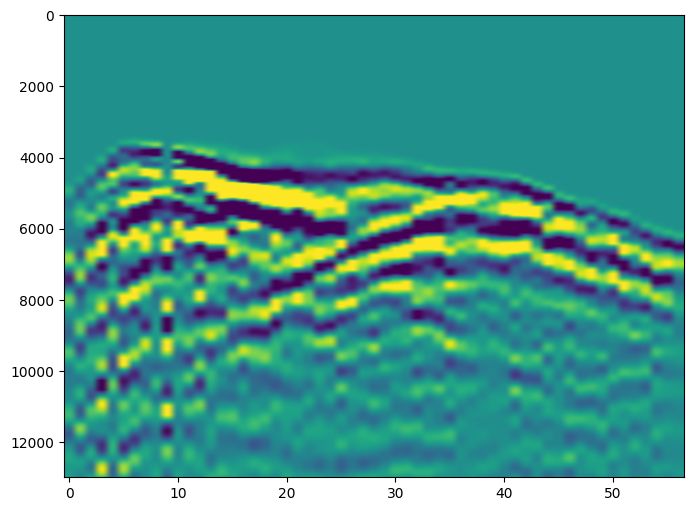

In [10]:
from matplotlib import pyplot as plt
qa = 0.005
plt.imshow(d_syn, aspect='auto', vmin=-qa, vmax=qa)
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.show()